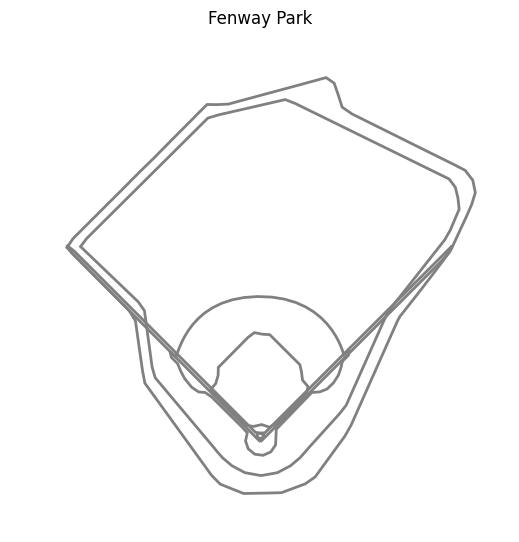

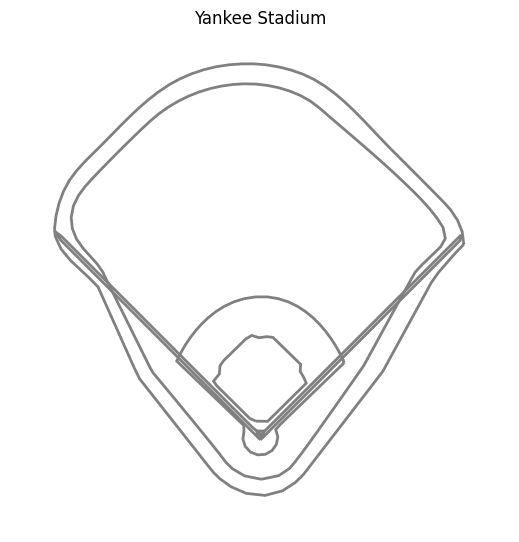

In [18]:
from pybaseball import plot_stadium

BOS = plot_stadium("red_sox")
NYY = plot_stadium("yankees")

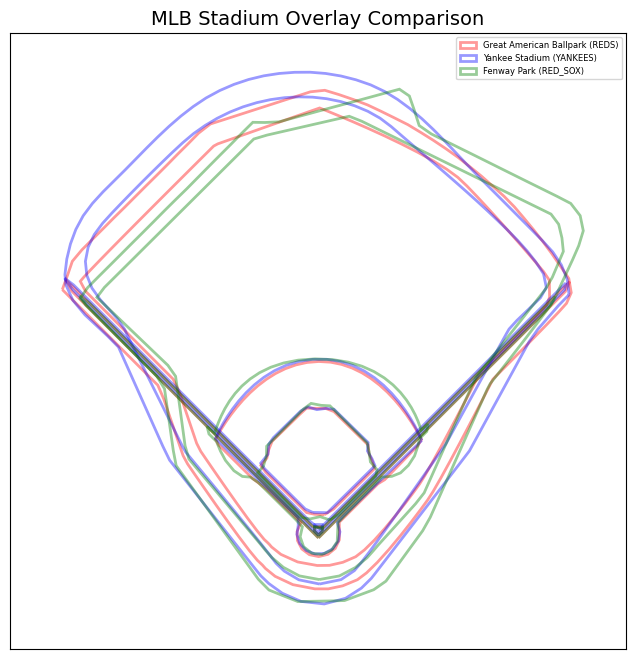

In [26]:
import matplotlib.pyplot as plt
from pybaseball import plot_stadium

import matplotlib.pyplot as plt
from pybaseball import plot_stadium
from pybaseball.plotting import STADIUM_COORDS

def overlay_stadiums(teams, colors=None, alphas=None, figsize=(10,8)):
    """
    疊加多個 MLB 球場外框（帶有球場名稱圖例）
    Args:
        teams (list[str]): 球隊英文代碼，例如 ["reds", "yankees", "red_sox"]
        colors (list[str]): 顏色列表
        alphas (list[float]): 透明度列表
        figsize (tuple): 圖片大小
    """
    
    fig, ax = plt.subplots(figsize=figsize)

    if colors is None:
        colors = ["red", "blue", "green", "orange", "purple", "brown"]
    if alphas is None:
        alphas = [0.4] * len(teams)

    labels = []  # 圖例用
    handles = [] # 存每隊 patch 的代表

    for i, team in enumerate(teams):
        before = len(ax.patches)
        plot_stadium(team, title="ignore", axis=ax)
        after = len(ax.patches)

        # 設定顏色透明度
        for p in ax.patches[before:after]:
            p.set_edgecolor(colors[i % len(colors)])
            p.set_alpha(alphas[i % len(alphas)])
            p.set_linewidth(2)

        # 從 pybaseball 內部表取球場名稱
        park_name = STADIUM_COORDS.loc[
            STADIUM_COORDS["team"] == team.lower(), "name"
        ].iloc[0]

        labels.append(f"{park_name} ({team.upper()})")

        # 用第一個 patch 當 legend 代表
        handles.append(ax.patches[before])

    # 外觀
    ax.set_xlim(0, 250)
    ax.set_ylim(-250, 0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("MLB Stadium Overlay Comparison", fontsize=14)

    # 加 legend：球場名稱 + 球隊縮寫
    ax.legend(handles, labels, loc="upper right", fontsize=6, frameon=True)

    plt.show()


overlay_stadiums(["reds", "yankees", "red_sox"], colors=["red", "blue", "green"])